# 1. Introduction
This teaching notebook asks a retrospective question: using information recorded during a 2-year observation period, how well can a model stratify records according to whether opioid use disorder (OUD) was documented in that same period?

The dataset column `OD` is retained for compatibility and represents the recorded OUD target. The model is decision support, not a diagnostic system or an autonomous clinical decision-maker.

Learning objectives:

1. Evaluate discrimination, calibration and errors without treating association or feature importance as causation
2. Translate an alert into a defined, nonjudgmental clinical review workflow
3. Select an operating threshold from validation data using explicit capacity and harm assumptions, then evaluate it once on the test set

The dataset is synthetic and supports classroom analysis only. It does not establish clinical validity or prospective performance.

Based on notebooks and documentation from the [Microsoft Responsible AI Toolbox](https://github.com/microsoft/responsible-ai-toolbox/tree/main/notebooks) and [scikit-learn probability calibration guidance](https://scikit-learn.org/stable/modules/calibration.html)


# 2. Data Set Characteristics

Number of instances: 1,000 patient-level records

Number of attributes: 20 predictive attributes and 1 target class

Temporal interpretation for this exercise:

- Index date: end of the 2-year observation period
- Predictor window: preceding 2 years
- Outcome recording: `OD` indicates whether OUD was documented in the same source 2-year period
- Limitation: the source does not establish that every predictor preceded the OUD diagnosis, so this is retrospective risk stratification rather than prospective incident prediction
- Prospective use would require a separate predictor window and future outcome horizon

Attribute information:

- `OD` target: recorded OUD diagnosis, where 1 = documented and 0 = not documented
- `Low_inc`: low income flag
- `Surgery`: major surgery recorded during the 2-year period
- `rx_ds`: cumulative opioid prescription days-supply filled during the 2-year period
- `A` to `V`: binary diagnosis or condition-group flags

`rx_ds` is a dispensing measure. It is not confirmed consumption or unique exposure days. Values above 730 therefore do not mean more than 730 unique days exposed, and the source does not document whether overlapping prescriptions were deduplicated


# 3. Setup
- responsibleai and raiwidgets provide RAIInsights and the dashboard
- fairlearn provides fairness metrics and mitigation algorithms used under the hood
- imbalanced-learn offers resampling utilities if you want to experiment with imbalance mitigation

In [ ]:
# Init placeholders for later RAI prep
train_df_rai = None
test_df_rai = None
feature_metadata = None

# Core libs
from pathlib import Path
from datetime import datetime
import numpy as np
from numpy import percentile
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau
from IPython.display import display, Markdown

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
    precision_score,
    recall_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    f1_score,
)

# Optional extras
try:
    import dice_ml  # counterfactual library
    _DICE = True
except Exception:
    _DICE = False

try:
    import econml  # causal library
    _ECONML = True
except Exception:
    _ECONML = False

# Course utilities
from utils import (
    positive_scores,
    auc_report,
    tradeoff_table,
    pick_threshold_cost,
    pick_threshold_recall_floor,
    pick_threshold_workload,
    summary_at_threshold,
    plot_recall_floor_curves,
    plot_cumulative_recall_at_threshold,
    plot_topk_at_threshold,
    make_thresholded_estimator,
    init_rai_dependencies,
)

# RAI dependency detection
rai_flags, rai_objects = init_rai_dependencies()
globals().update(rai_flags)
globals().update(rai_objects)

# Repro seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Quick status
print(f"_RAI={_RAI}, _INTERPRET={_INTERPRET}, _ERRANALYSIS={_ERRANALYSIS}, _FAIRLEARN={_FAIRLEARN}, _DICE={_DICE}, _ECONML={_ECONML}")



_RAI=True, _INTERPRET=True, _ERRANALYSIS=True, _FAIRLEARN=True, _DICE=True, _ECONML=True


# 4. Data Load & preparation

In [2]:
# Path to your CSV (update if needed for your system)
DATA_PATH = "./Data/opiod_raw_data.csv"

df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (1000, 22)


,ID,OD,Low_inc,SURG,rx ds,A,B,C,D,E,...,I,J,K,L,M,N,R,S,T,V
0,1,1,1,0,516,0,0,0,1,0,...,1,0,1,1,1,0,1,0,0,0
1,2,1,1,0,119,0,0,1,0,0,...,1,1,0,0,1,1,1,1,0,0
2,3,1,1,1,925,1,1,0,1,1,...,1,0,0,0,1,0,1,0,1,0
3,4,0,1,0,393,1,1,0,0,0,...,0,0,1,1,1,0,1,1,1,0
4,5,1,1,0,630,0,0,0,0,1,...,0,0,0,0,1,1,1,0,0,0


In [3]:
# Recorded OUD prevalence and missingness

TARGET = "OD"  # dataset column: 1 = recorded OUD diagnosis, 0 = not recorded

counts = df_raw[TARGET].value_counts(dropna=False)
prevalence_percent = counts.get(1, 0) / counts.sum() * 100
positives_per_1000 = counts.get(1, 0) / counts.sum() * 1000

print("Recorded OUD counts:")
print(counts)
print(f"\nRecorded OUD prevalence: {prevalence_percent:.2f}%")
print(f"Records with documented OUD per 1,000: {positives_per_1000:.1f}")

Recorded OUD counts:
0    819
1    181
Name: OD, dtype: int64

Recorded OUD prevalence: 18.10%
Records with documented OUD per 1,000: 181.0


## 4.1. Basic cleaning, provenance and schema alignment

The supplied synthetic file contains one row per record. The analysis treats all predictors as available at scoring at the end of the 2-year observation period, while acknowledging that their order relative to OUD documentation is unknown


In [4]:
# Create a copy of the raw DataFrame
df = df_raw.copy()

# Standardize column names
df.columns = [c.strip().replace(" ", "_").replace("-", "_") for c in df.columns]

# Drop the identifier by name, not by position
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

# Harmonize known aliases
if "SURG" in df.columns and "Surgery" not in df.columns:
    df = df.rename(columns={"SURG": "Surgery"})

expected_cols = [
    "OD", "Low_inc", "Surgery", "rx_ds",
    "A", "B", "C", "D", "E", "F", "H", "I", "J", "K", "L", "M", "N", "R", "S", "T", "V"
]
missing = [c for c in expected_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")


def to_binary(s: pd.Series) -> pd.Series:
    if s.dtype == "O":
        mapped = s.astype(str).str.strip().str.lower().map({
            "1": 1, "0": 0, "y": 1, "n": 0,
            "yes": 1, "no": 0, "true": 1, "false": 0
        })
        return pd.to_numeric(mapped, errors="coerce")
    return pd.to_numeric(s, errors="coerce")


binary_candidates = [c for c in expected_cols if c != "rx_ds"]
df[binary_candidates] = df[binary_candidates].apply(to_binary)
df["rx_ds"] = pd.to_numeric(df["rx_ds"], errors="coerce")

rx_over_730 = int((df["rx_ds"] > 730).sum())
data_audit = pd.DataFrame({
    "Measure": ["Records", "Missing cells", "Duplicate rows", "Minimum rx_ds", "Maximum rx_ds", "rx_ds above 730"],
    "Value": [len(df), int(df.isna().sum().sum()), int(df.duplicated().sum()), float(df["rx_ds"].min()), float(df["rx_ds"].max()), rx_over_730],
    "Interpretation": [
        "Synthetic patient-level records",
        "After schema alignment",
        "Across analysis columns",
        "Cumulative prescription days-supply filled",
        "Not unique exposure days",
        "Does not imply more than 730 unique days exposed",
    ],
})
display(data_audit)
df.head()

,Measure,Value,Interpretation
0,Records,1000.0,Synthetic patient-level records
1,Missing cells,0.0,After schema alignment
2,Duplicate rows,3.0,Across analysis columns
3,Minimum rx_ds,0.0,Cumulative prescription days-supply filled
4,Maximum rx_ds,1923.0,Not unique exposure days
5,rx_ds above 730,204.0,Does not imply more than 730 unique days exposed


,OD,Low_inc,Surgery,rx_ds,A,B,C,D,E,F,...,I,J,K,L,M,N,R,S,T,V
0,1,1,0,516,0,0,0,1,0,1,...,1,0,1,1,1,0,1,0,0,0
1,1,1,0,119,0,0,1,0,0,1,...,1,1,0,0,1,1,1,1,0,0
2,1,1,1,925,1,1,0,1,1,0,...,1,0,0,0,1,0,1,0,1,0
3,0,1,0,393,1,1,0,0,0,1,...,0,0,1,1,1,0,1,1,1,0
4,1,1,0,630,0,0,0,0,1,1,...,0,0,0,0,1,1,1,0,0,0


# 5. Training, Validation and Testing - 80/15/5 stratified split

- Training set: fit model parameters
- Validation set: inspect calibration and select the threshold policy
- Test set: one final evaluation after the model and threshold are locked

The 5% test set contains only 50 records, so counts and uncertainty intervals must accompany rates


In [5]:
target_col = "OD"
num_cols = ["rx_ds"]

# Infer binary columns: columns with only 0/1 values, excluding target and numeric columns
binary_cols = [col for col in df.columns
               if col not in [target_col] + num_cols
               and set(df[col].dropna().unique()).issubset({0, 1})]

cat_like_binary_cols = binary_cols.copy()

X = df[num_cols + cat_like_binary_cols].copy()
y = df[target_col].copy()

# 80% train, 20% temporary holdout
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Split temporary holdout into 15% validation and 5% test overall
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE
)
# Display shapes and class distributions as a DataFrame

info = {
    "Set": ["Train", "Validation", "Overall"],
    "X shape": [X_train.shape, X_val.shape, X.shape],
    "y shape": [y_train.shape, y_val.shape, y.shape],
    "p(recorded OUD=0)": [
        y_train.value_counts(normalize=True).get(0, 0.0),
        y_val.value_counts(normalize=True).get(0, 0.0),
        y.value_counts(normalize=True).get(0, 0.0),
    ],
    "p(recorded OUD=1)": [
        y_train.value_counts(normalize=True).get(1, 0.0),
        y_val.value_counts(normalize=True).get(1, 0.0),
        y.value_counts(normalize=True).get(1, 0.0),
    ],
}

df_info = pd.DataFrame(info)
display(df_info.style.format({"p(recorded OUD=0)": "{:.3f}", "p(recorded OUD=1)": "{:.3f}"}))

,Set,X shape,y shape,p(recorded OUD=0),p(recorded OUD=1)
0,Train,"(800, 20)","(800,)",0.819,0.181
1,Validation,"(150, 20)","(150,)",0.820,0.180
2,Overall,"(1000, 20)","(1000,)",0.819,0.181


## 5.1. Modeling pipeline, training, and calibration

### Setting a baseline
A naive majority-class baseline clarifies the minimum standard any model must beat, highlighting the danger of ignoring minority patients and ensuring improvements carry meaningful weight in healthcare decision making

**ROC AUC**  
- 0.5 → no discrimination
- 0.6–0.7 → poor
- 0.7–0.8 → fair
- 0.8–0.9 → good
- ≥ 0.9 → excellent

**PR AUC**  
- Must be interpreted against event prevalence `p` in the validation set  

Dummy baseline
PR AUC: 0.180
ROC AUC: 0.500
Prevalence p = 0.180  |  PR AUC lift = 1.00× over baseline


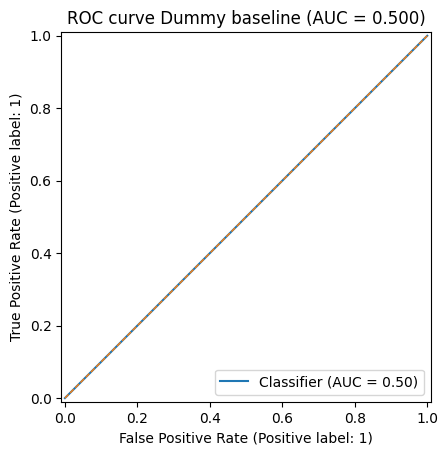

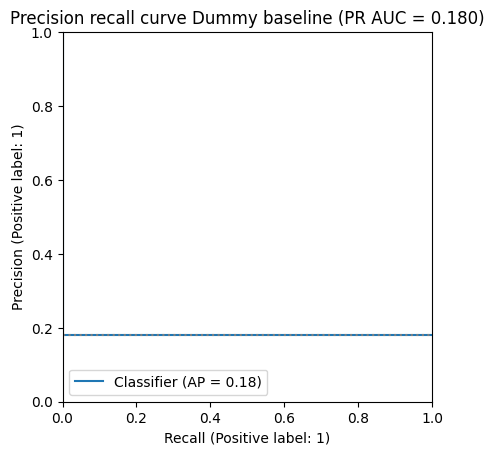

In [6]:
# Baseline: DummyClassifier (majority class)
dummy_clf = DummyClassifier(
    strategy="most_frequent", random_state=RANDOM_STATE)
dummy_clf.fit(X_train, y_train)

# Evaluate on validation
y_score_val = positive_scores(dummy_clf, X_val)
metrics_dummy = auc_report(
    y_val, y_score_val, name="Dummy baseline", plot=True)

## 5.2. Preprocesing our Pipeline

[Scikit-learn preprocessing](https://scikit-learn.org/stable/api/sklearn.preprocessing.html) standardizes and transforms features for modeling, including scaling, encoding, and imputation. Helping to maintain a consistent data transformation workflow

In [7]:
# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=True, with_std=True))
])

binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("bin", binary_transformer, cat_like_binary_cols)
    ],
    remainder="drop",  # drops any column not in previously specified
    verbose_feature_names_out=False  # keeps original feature names
)

# Logistic Regression baseline with variance filter
base_clf = Pipeline(steps=[
    ("prep", preprocess),
    # Eliminates features with zero variance
    ("varth", VarianceThreshold(threshold=0.0)),
    ("model", LogisticRegression(
        solver="liblinear",  # See details in course material
        class_weight="balanced",  # Adjusts weights for class imbalance
        random_state=RANDOM_STATE,
        max_iter=200
    ))
])

### Basic preliminary model performance check

base_clf
PR AUC: 0.495
ROC AUC: 0.750
Prevalence p = 0.180  |  PR AUC lift = 2.75× over baseline


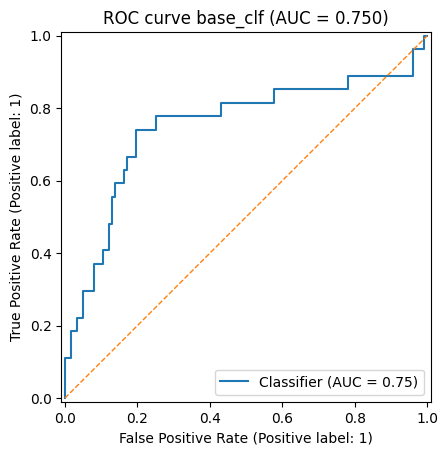

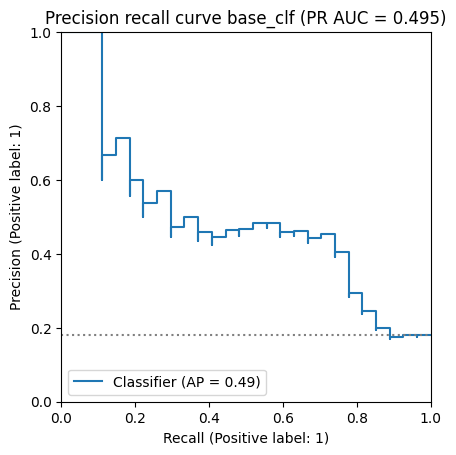

In [8]:
# Fit base model
base_clf.fit(X_train, y_train)

# Evaluate on validation
y_score_val = positive_scores(base_clf, X_val)
metrics_base = auc_report(y_val, y_score_val, name="base_clf", plot=True)

In [9]:
# Five patients: raw pre-calibration score, predicted label, actual label

tbl5 = (
    pd.DataFrame(
        {
            "raw_score": positive_scores(base_clf, X_val),
            "actual": y_val.loc[X_val.index].astype(int),
        },
        index=X_val.index,
    )
    .assign(predicted=lambda d: (d["raw_score"] >= 0.50).astype(int))  # threshold before calibration
    .round({"raw_score": 3})
    .sample(n=10, random_state=7)
    .reset_index()
    .rename(columns={"index": "patient"})
    .loc[:, ["patient", "raw_score", "predicted", "actual"]]
)

display(tbl5)


,patient,raw_score,predicted,actual
0,641,0.274,0,0
1,466,0.799,1,1
2,993,0.415,0,0
3,860,0.278,0,0
4,486,0.211,0,0
5,305,0.560,1,0
6,166,0.270,0,0
7,24,0.636,1,0
8,602,0.396,0,0
9,573,0.326,0,0


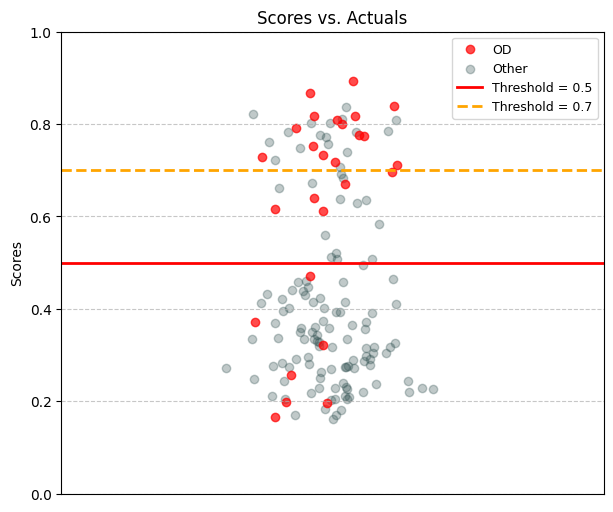

In [10]:
# Data for the plot using variables from the preceding cells
scores = positive_scores(base_clf, X_val)
actuals = y_val

# Separate scores for actual positive (OD=1) and negative (OD=0) cases
scores_positive = scores[actuals == 1]
scores_negative = scores[actuals == 0]

# Generate random jitter for the x-axis
jitter_strength = 0.03
jitter_positive = np.random.normal(0, jitter_strength, len(scores_positive))
jitter_negative = np.random.normal(0, jitter_strength, len(scores_negative))

# 3. Create the plot
fig, ax = plt.subplots(figsize=(7, 6))
scatter_other = ax.scatter(jitter_negative, scores_negative, color='darkslategrey', alpha=0.3, label='Other')
scatter_target = ax.scatter(jitter_positive, scores_positive, color='red', alpha=0.7, label='OD')

# Add threshold lines
line_50 = ax.axhline(y=0.5, color='red', linestyle='-', linewidth=2, label='Threshold = 0.5')
line_80 = ax.axhline(y=0.7, color='orange', linestyle='--', linewidth=2, label='Threshold = 0.7')

ax.set_title('Scores vs. Actuals')
ax.set_ylabel('Scores')
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_xlim(-0.2, 0.2) # Set fixed x-axis limits to control the visual spread
ax.legend(handles=[scatter_target, scatter_other, line_50, line_80], fontsize=9, loc='upper right')

ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 6. Recalibrating the Scores

**1. Reliable probabilities**  
- Turns raw scores into real probabilities  
- Ensures predictions match observed outcome frequencies  
- Prevents overly high or low risk estimates  

**2. Better clinical decisions**  
- Essential when risk values guide medical choices  
- Supports thresholds with clear clinical meaning
- Reduces wasted clinical resources  

**3. Trust and adoption**  
- Builds trust in AI decisions  
- Enables safer patient outcomes

In [11]:
# Calibrate probabilities using CV on training data
calibrated_clf = CalibratedClassifierCV(
    estimator=base_clf,
    method="sigmoid",
    cv=5
)
calibrated_clf.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('prep',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median')),
                                                                                                   ('scaler',
                                                                                                    StandardScaler())]),
                                                                                   ['rx_ds']),
                                                                                  ('bin',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='most_frequent'))]),
                                                                                   ['Low_inc',
                                                                                    'Surgery',
                                                                                    'A',
                                                                                    'B',
                                                                                    'C',
                                                                                    'D',
                                                                                    'E',
                                                                                    'F',
                                                                                    'H',
                                                                                    'I',
                                                                                    'J',
                                                                                    'K',
                                                                                    'L',
                                                                                    'M',
                                                                                    'N',
                                                                                    'R',
                                                                                    'S',
                                                                                    'T',
                                                                                    'V'])],
                                                                    verbose_feature_names_out=False)),
                                                 ('varth', VarianceThreshold()),
                                                 ('model',
                                                  LogisticRegression(class_weight='balanced',
                                                                     max_iter=200,
                                                                     random_state=42,
                                                                     solver='liblinear'))]))

,Risk_band,Records,Avg_pred_before,Observed_OUD_rate,Avg_pred_after
0,Q1,15,0.191,0.200,0.073
1,Q2,15,0.232,0.000,0.087
2,Q3,15,0.275,0.067,0.101
3,Q4,15,0.312,0.067,0.113
4,Q5,15,0.350,0.000,0.126
5,Q6,15,0.404,0.067,0.145
6,Q7,15,0.477,0.067,0.177
7,Q8,15,0.657,0.467,0.276
8,Q9,15,0.754,0.333,0.350
9,Q10,15,0.820,0.533,0.421


Validation records represented: 150 of 150


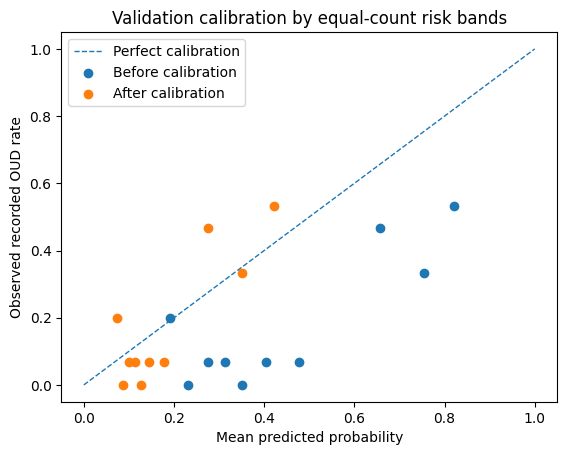

In [12]:
# Quantile bands on validation only; keep the test set closed
base_clf_uncal = clone(base_clf).fit(X_train, y_train)
p_before = base_clf_uncal.predict_proba(X_val)[:, 1]
p_after = calibrated_clf.predict_proba(X_val)[:, 1]

df_cal = pd.DataFrame({
    "Recorded_OUD": y_val.values,
    "Pred_before": p_before,
    "Pred_after": p_after,
}, index=X_val.index)

df_cal["Risk_band"] = pd.qcut(
    df_cal["Pred_after"], q=10,
    labels=[f"Q{i}" for i in range(1, 11)],
    duplicates="drop",
)

calibration_summary = (
    df_cal.groupby("Risk_band", observed=True)
    .agg(
        Records=("Recorded_OUD", "size"),
        Avg_pred_before=("Pred_before", "mean"),
        Observed_OUD_rate=("Recorded_OUD", "mean"),
        Avg_pred_after=("Pred_after", "mean"),
    )
    .reset_index()
    .round(3)
)
display(calibration_summary)
print(f"Validation records represented: {int(calibration_summary['Records'].sum())} of {len(X_val)}")

plt.figure()
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Perfect calibration")
plt.scatter(
    calibration_summary["Avg_pred_before"],
    calibration_summary["Observed_OUD_rate"],
    label="Before calibration",
)
plt.scatter(
    calibration_summary["Avg_pred_after"],
    calibration_summary["Observed_OUD_rate"],
    label="After calibration",
)
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed recorded OUD rate")
plt.title("Validation calibration by equal-count risk bands")
plt.legend()
plt.show()

### Compare base_clf vs calibrated_clf on validation

In [13]:
# Focus on discrimination equality and calibration improvements

# Scores
y_score_val_base = positive_scores(base_clf, X_val)
y_score_val_cal = positive_scores(calibrated_clf, X_val)

# Discrimination
roc_base = roc_auc_score(y_val, y_score_val_base)
pr_base = average_precision_score(y_val, y_score_val_base)
roc_cal = roc_auc_score(y_val, y_score_val_cal)
pr_cal = average_precision_score(y_val, y_score_val_cal)

# Calibration
ll_base = log_loss(y_val, np.clip(y_score_val_base, 1e-6, 1 - 1e-6))
ll_cal = log_loss(y_val, np.clip(y_score_val_cal,  1e-6, 1 - 1e-6))
brier_base = brier_score_loss(y_val, y_score_val_base)
brier_cal = brier_score_loss(y_val, y_score_val_cal)

# Assemble into dataframe
metrics_df = pd.DataFrame([
    {"Metric": "ROC AUC", "Base": roc_base, "Calibrated": roc_cal, "Explanation": "Ability to distinguish between classes (higher is better)"},
    {"Metric": "PR AUC", "Base": pr_base, "Calibrated": pr_cal, "Explanation": "Precision-recall curve area; useful for imbalanced data"},
    {"Metric": "Log loss", "Base": ll_base, "Calibrated": ll_cal, "Explanation": "Penalty for incorrect and overconfident predictions (lower is better)"},
    {"Metric": "Brier score", "Base": brier_base, "Calibrated": brier_cal, "Explanation": "Mean squared error of predicted probabilities (lower is better)"},
])

display(metrics_df.style.format({"Base": "{:.3f}", "Calibrated": "{:.3f}"}))

,Metric,Base,Calibrated,Explanation
0,ROC AUC,0.750,0.750,Ability to distinguish between classes (higher is better)
1,PR AUC,0.495,0.497,Precision-recall curve area; useful for imbalanced data
2,Log loss,0.589,0.400,Penalty for incorrect and overconfident predictions (lower is better)
3,Brier score,0.198,0.123,Mean squared error of predicted probabilities (lower is better)


# 7. Choosing when a predicted probability triggers a clinical review

Hypothetical teaching workflow:

`risk alert -> structured clinician review -> clinical assessment or specialist consultation/referral if warranted`

The user is a prescribing clinician or relevant clinical team. Before the next relevant opioid-care or prescribing decision, the team reviews the person's history, diagnoses, comorbidities and clinical context, then discusses concerns through nonjudgmental shared decision-making. The alert does not diagnose OUD and must not automatically deny treatment, taper medication or discontinue care. Accountability remains with the clinician or clinical team

This workflow is illustrative and has not been clinically validated. It follows the regulator principle that intended users, workflow and limitations should be made clear: [United States Food and Drug Administration transparency principles](https://www.fda.gov/medical-devices/software-medical-device-samd/transparency-machine-learning-enabled-medical-devices-guiding-principles)


,TP,FP,FN,recall,precision,alert_count,alerts_per_1000
threshold,,,,,,,
0.1,23,90,4,0.852,0.204,113,753.333
0.2,20,26,7,0.741,0.435,46,306.667
0.3,16,17,11,0.593,0.485,33,220.000
0.4,6,4,21,0.222,0.600,10,66.667
0.5,1,0,26,0.037,1.000,1,6.667


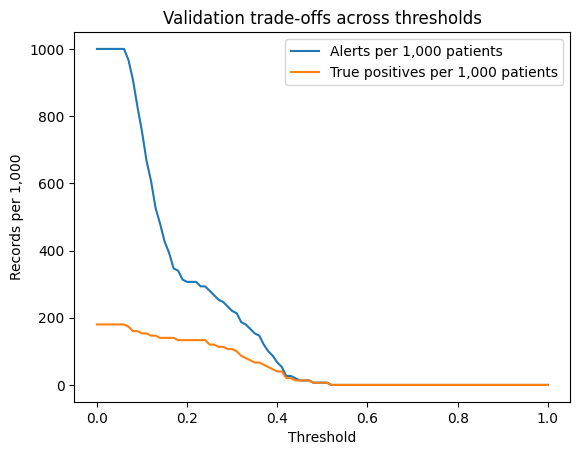

In [14]:
# Calibrated validation probabilities and common threshold grid
y_score_val = positive_scores(calibrated_clf, X_val)
THRESHOLD_GRID = np.linspace(0, 1, 101)
df_thr = tradeoff_table(y_val, y_score_val, thresholds=THRESHOLD_GRID)
df_thr["alert_count"] = df_thr["TP"] + df_thr["FP"]

display(
    df_thr.query("threshold in [0.1, 0.2, 0.3, 0.4, 0.5]")
    .loc[:, ["threshold", "TP", "FP", "FN", "recall", "precision", "alert_count", "alerts_per_1000"]]
    .round(3)
    .set_index("threshold")
)

plt.figure()
plt.plot(df_thr["threshold"], df_thr["alerts_per_1000"], label="Alerts per 1,000 patients")
plt.plot(df_thr["threshold"], df_thr["true_pos_per_1000"], label="True positives per 1,000 patients")
plt.xlabel("Threshold")
plt.ylabel("Records per 1,000")
plt.title("Validation trade-offs across thresholds")
plt.legend()
plt.show()

## 7.1. Three separate threshold analyses

Thresholds encode policy choices rather than purely technical choices. We examine three distinct questions on validation data:

1. Workload analysis: what threshold stays within 300 alerts per 1,000 patients?
2. Recall-floor analysis: what threshold reaches the illustrative 60% validation recall target with highest precision?
3. Harm sensitivity analysis: how does the preferred threshold change when a false negative receives 2, 5 or 10 harm points for every 1 false-positive harm point?

The primary rule later combines only the approved capacity and recall constraints, then selects the feasible threshold with highest precision. No test result contributes to that choice


### 7.1.1. Workload-only analysis on validation

Illustrative capacity: no more than 300 alerts per 1,000 patients. This analysis does not impose the recall target


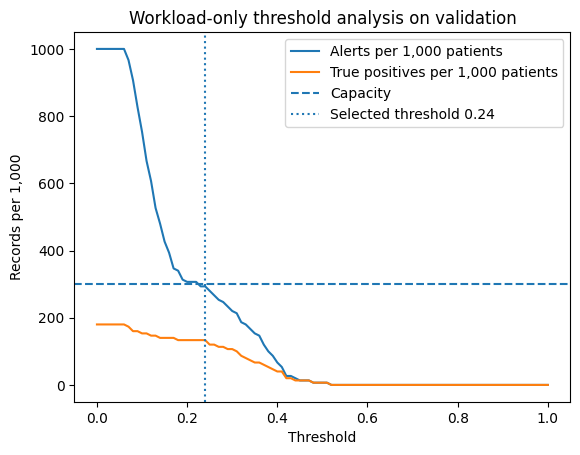

,threshold,precision,recall,TP,FP,TN,FN,alerts_per_1000,true_pos_per_1000
0,0.24,0.455,0.741,20,24,99,7,293.333,133.333


In [15]:
MAX_REVIEW_CAPACITY_PER_1000 = 300.0

workload_result = pick_threshold_workload(
    y_val, y_score_val, alerts_per_1000_max=MAX_REVIEW_CAPACITY_PER_1000
)
workload_table = workload_result["table"]
THR_WORKLOAD = float(workload_result["threshold"])

plt.figure()
plt.plot(workload_table["threshold"], workload_table["alerts_per_1000"], label="Alerts per 1,000 patients")
plt.plot(workload_table["threshold"], workload_table["true_pos_per_1000"], label="True positives per 1,000 patients")
plt.axhline(MAX_REVIEW_CAPACITY_PER_1000, linestyle="--", label="Capacity")
plt.axvline(THR_WORKLOAD, linestyle=":", label=f"Selected threshold {THR_WORKLOAD:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Records per 1,000")
plt.title("Workload-only threshold analysis on validation")
plt.legend()
plt.show()

display(summary_at_threshold(y_val, y_score_val, THR_WORKLOAD).round(3))

Let's now see the risk groups by decile (bands), and visualizes the overall risk score distribution, with optional threshold overlay and decile boundaries

,n,positives,min_score,max_score,prevalence,cum_capture,alerts_per_1000,true_pos_per_1000
band,,,,,,,,
1,15,8,0.381,0.520,0.533,0.296,100.0,53.333
2,15,5,0.316,0.378,0.333,0.481,100.0,33.333
3,15,7,0.229,0.316,0.467,0.741,100.0,46.667
4,15,1,0.159,0.221,0.067,0.778,100.0,6.667
5,15,1,0.135,0.156,0.067,0.815,100.0,6.667
6,15,0,0.121,0.134,0.000,0.815,100.0,0.000
7,15,1,0.106,0.120,0.067,0.852,100.0,6.667
8,15,1,0.097,0.105,0.067,0.889,100.0,6.667
9,15,0,0.083,0.093,0.000,0.889,100.0,0.000


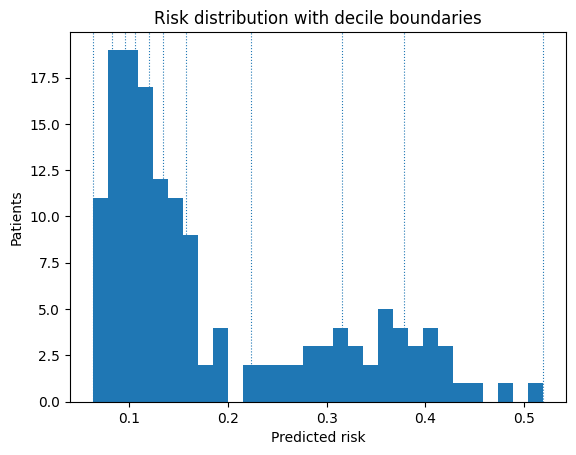

In [16]:
N_BINS = 10  # deciles by default
y_score_val = positive_scores(calibrated_clf, X_val)

# Build bands by quantiles, highest risk = band 1
bands = pd.qcut(y_score_val, q=N_BINS, labels=False, duplicates="drop")
# qcut labels lowest=0..highest=K-1, invert so 1 is highest-risk band
bands = (bands.max() - bands) + 1

df = pd.DataFrame({
    "y_true": y_val.astype(int),
    "score": y_score_val,
    "band": bands.astype(int),
})

summ = (df.groupby("band", as_index=True)
          .agg(n=("y_true","size"),
               positives=("y_true","sum"),
               min_score=("score","min"),
               max_score=("score","max"))
          .sort_index())

summ["prevalence"] = summ["positives"] / summ["n"]
summ["cum_capture"] = summ["positives"].cumsum() / df["y_true"].sum()
summ["alerts_per_1000"] = 1000.0 * summ["n"] / len(df)
summ["true_pos_per_1000"] = 1000.0 * summ["positives"] / len(df)

display(summ.round(3))

# Optional threshold overlay if you already chose one, else set THR=None
THR = None  # e.g., THR = 0.23

# Histogram of risk scores with decile edges
plt.figure()
plt.hist(df["score"], bins=30)
if THR is not None:
    plt.axvline(THR, linestyle="--")
# draw decile boundaries
edges = np.quantile(df["score"], np.linspace(0,1,N_BINS+1))
for x in edges:
    plt.axvline(x, linestyle=":", linewidth=0.8)
plt.xlabel("Predicted risk")
plt.ylabel("Patients")
plt.title("Risk distribution with decile boundaries")
plt.show()


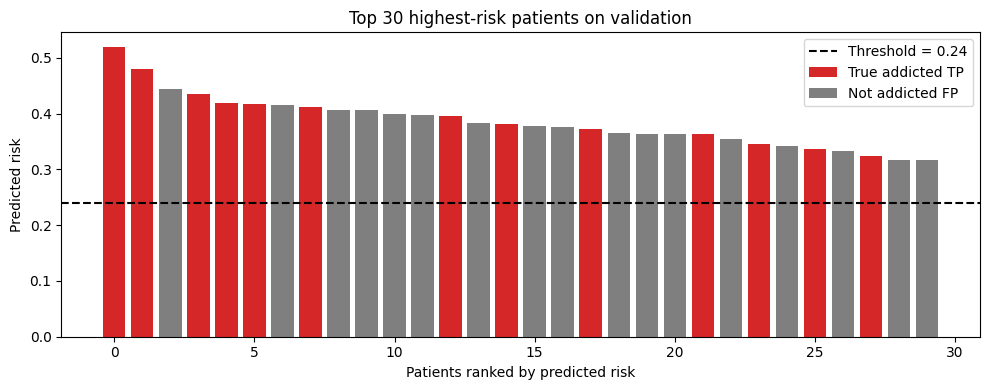

In [17]:
# Patient-level prioritisation view at the workload-only threshold
plot_topk_at_threshold(y_val, y_score_val, chosen_threshold=THR_WORKLOAD, top_k=30)

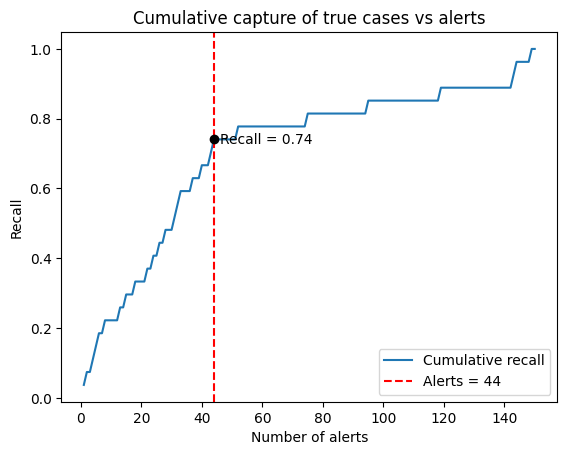

In [18]:
# Cumulative validation recall versus alerts at the workload-only threshold
plot_cumulative_recall_at_threshold(y_val, y_score_val, chosen_threshold=THR_WORKLOAD)

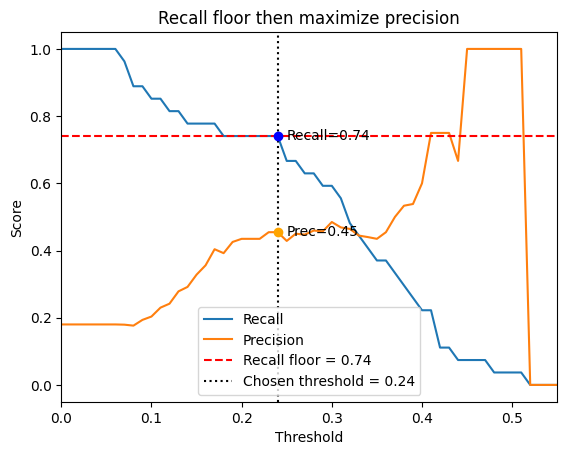

In [19]:
# Precision and recall at the workload-only threshold
workload_summary = summary_at_threshold(y_val, y_score_val, THR_WORKLOAD)
workload_recall = float(workload_summary["recall"].iloc[0])
plot_recall_floor_curves(y_val, y_score_val, recall_floor=workload_recall, chosen_threshold=THR_WORKLOAD)

### 7.1.2. Recall-floor-only analysis on validation

The illustrative target is validation recall of at least 60%. Among thresholds meeting that target, this analysis selects the one with highest precision. Achieving the target on validation does not guarantee the same recall in new patients


,threshold,precision,recall,TP,FP,TN,FN,alerts_per_1000,true_pos_per_1000
0,0.28,0.459,0.63,17,20,103,10,246.667,113.333


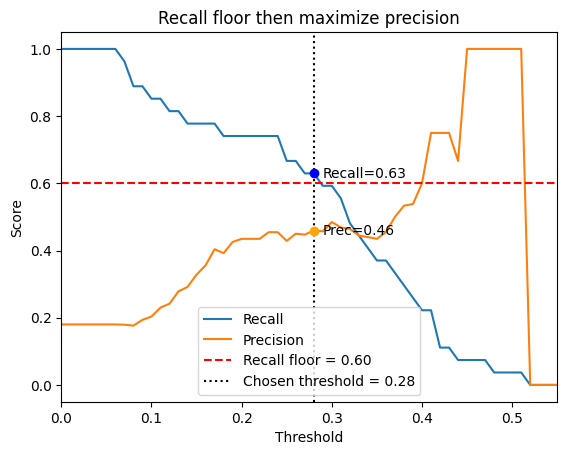

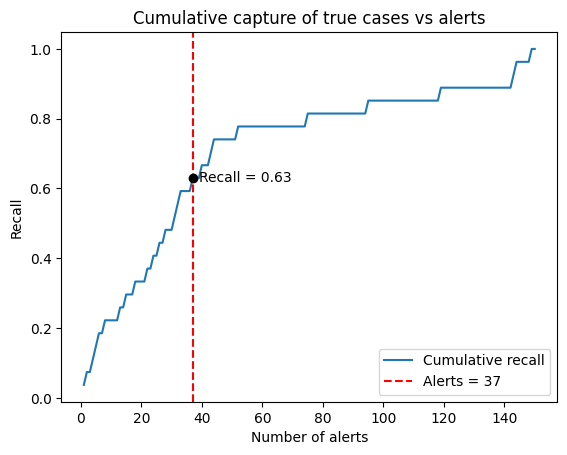

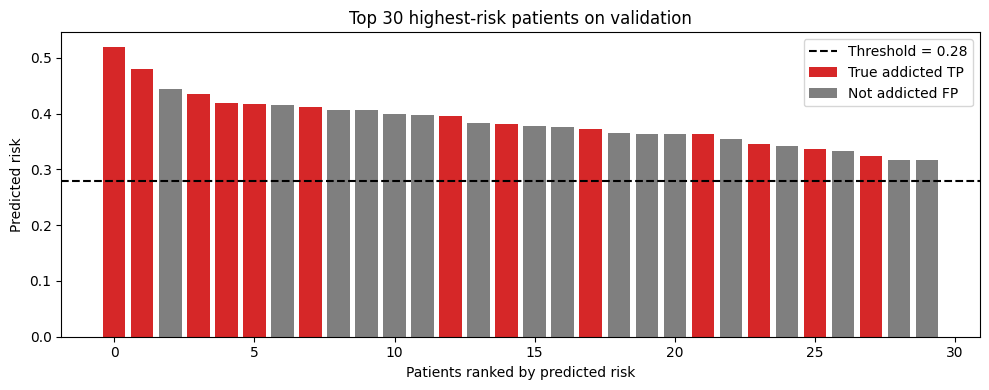

In [20]:
MIN_VALIDATION_RECALL = 0.60

recall_result = pick_threshold_recall_floor(
    y_val, y_score_val, recall_floor=MIN_VALIDATION_RECALL
)
THR_RECALL = float(recall_result["threshold"])

display(summary_at_threshold(y_val, y_score_val, THR_RECALL).round(3))
plot_recall_floor_curves(
    y_val, y_score_val,
    recall_floor=MIN_VALIDATION_RECALL,
    chosen_threshold=THR_RECALL,
)
plot_cumulative_recall_at_threshold(y_val, y_score_val, chosen_threshold=THR_RECALL)
plot_topk_at_threshold(y_val, y_score_val, chosen_threshold=THR_RECALL, top_k=30)

### 7.1.3. Harm-point sensitivity analysis on validation

Harm points are illustrative academic inputs, not monetary costs or measured clinical utilities. A false positive means an additional structured review, not automatic undertreatment. A false negative means no model-triggered review for a record with documented OUD. We test false-negative to false-positive ratios of 2:1, 5:1 and 10:1


In [21]:
FP_HARM_POINTS = 1.0
FN_HARM_RATIOS = [2.0, 5.0, 10.0]

harm_rows = []
for fn_ratio in FN_HARM_RATIOS:
    harm_result = pick_threshold_cost(
        y_val, y_score_val,
        C_FP=FP_HARM_POINTS,
        C_FN=fn_ratio * FP_HARM_POINTS,
    )
    threshold = float(harm_result["threshold_empirical"])
    row = summary_at_threshold(y_val, y_score_val, threshold).iloc[0].to_dict()
    row.update({
        "FN:FP harm ratio": f"{fn_ratio:.0f}:1",
        "total harm points": FP_HARM_POINTS * row["FP"] + fn_ratio * FP_HARM_POINTS * row["FN"],
    })
    harm_rows.append(row)

harm_sensitivity = pd.DataFrame(harm_rows)[[
    "FN:FP harm ratio", "threshold", "TP", "FP", "FN", "recall",
    "precision", "alerts_per_1000", "total harm points"
]]
display(harm_sensitivity.round(3))

# Keep the approved primary 5:1 inputs available for reporting
C_FP = FP_HARM_POINTS
C_FN = 5.0 * FP_HARM_POINTS
THR_HARM_5 = float(harm_sensitivity.loc[
    harm_sensitivity["FN:FP harm ratio"] == "5:1", "threshold"
].iloc[0])

,FN:FP harm ratio,threshold,TP,FP,FN,recall,precision,alerts_per_1000,total harm points
0,2:1,0.23,20.0,24.0,7.0,0.741,0.455,293.333,38.0
1,5:1,0.23,20.0,24.0,7.0,0.741,0.455,293.333,59.0
2,10:1,0.17,21.0,31.0,6.0,0.778,0.404,346.667,91.0


Validation visualisation for the 5:1 harm ratio at threshold 0.23


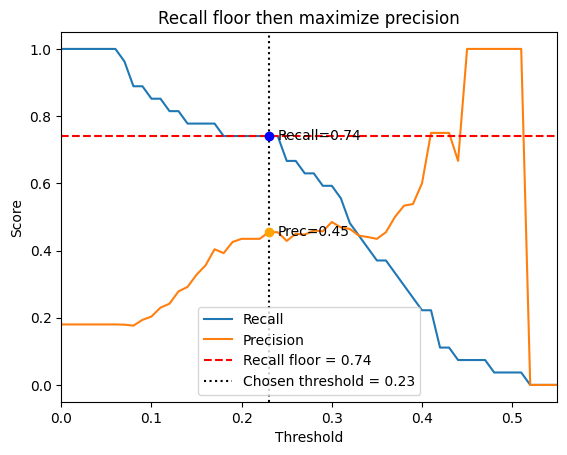

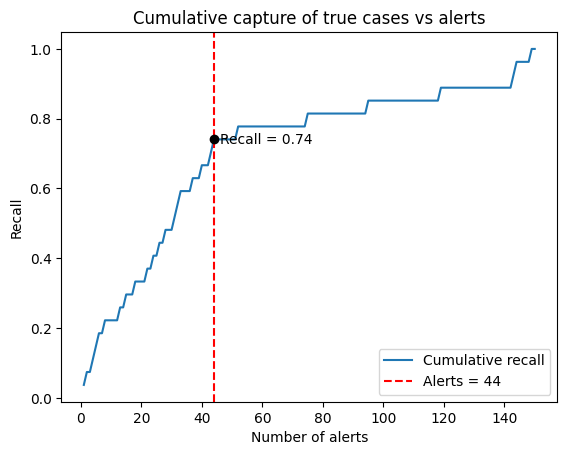

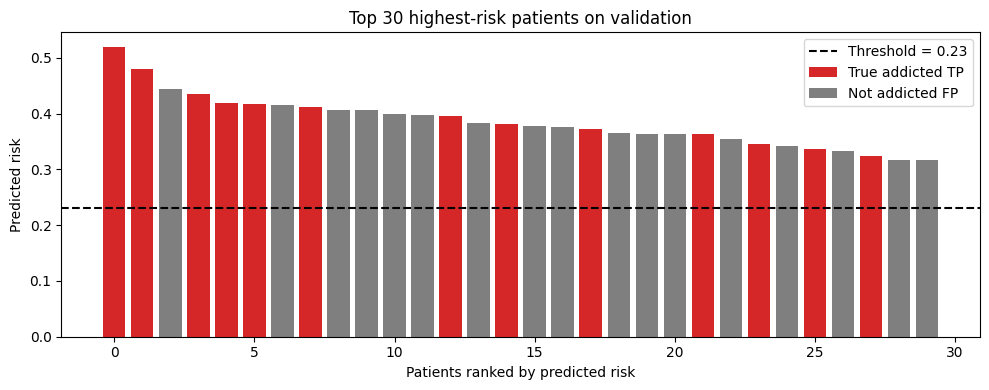

In [22]:
# Visualise the primary 5:1 harm assumption without making it the governing rule
harm_5_summary = summary_at_threshold(y_val, y_score_val, THR_HARM_5)
harm_5_recall = float(harm_5_summary["recall"].iloc[0])
print(f"Validation visualisation for the 5:1 harm ratio at threshold {THR_HARM_5:.2f}")
plot_recall_floor_curves(
    y_val, y_score_val,
    recall_floor=harm_5_recall,
    chosen_threshold=THR_HARM_5,
)
plot_cumulative_recall_at_threshold(y_val, y_score_val, chosen_threshold=THR_HARM_5)
plot_topk_at_threshold(y_val, y_score_val, chosen_threshold=THR_HARM_5, top_k=30)

# 8. Freeze the Threshold Policy, Then Evaluate Once on Test

Primary validation-only rule:

1. Require recall of at least 60%
2. Require no more than 300 alerts per 1,000 patients
3. Among feasible thresholds, select the one with highest precision
4. If none is feasible, report infeasibility rather than weakening the rule after viewing test results

The final threshold is frozen before any test prediction is calculated


| Analysis | Question answered | Governing role |
| :--- | :--- | :--- |
| Workload only | Which threshold fits capacity? | Supporting analysis |
| Recall floor only | Which threshold meets the validation recall target with highest precision? | Supporting analysis |
| Harm sensitivity | How does the choice respond to assumed relative harms? | Sensitivity analysis |
| Joint primary rule | Which threshold meets both approved constraints and has highest precision? | Final validation-only selection rule |


The test set remains closed while the candidate table is filtered and ranked. Validation uncertainty describes sampling uncertainty in this teaching split, while the 60% recall value remains a policy target rather than a promise of future performance


In [23]:
from scipy.stats import norm


def wilson_interval(successes, total, confidence=0.95):
    if total == 0:
        return (np.nan, np.nan)
    z = norm.ppf(1 - (1 - confidence) / 2)
    p = successes / total
    denominator = 1 + z**2 / total
    centre = (p + z**2 / (2 * total)) / denominator
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * total)) / total) / denominator
    return (centre - margin, centre + margin)


# Primary policy selection uses validation predictions only
policy_candidates = df_thr.copy()
policy_candidates["alert_count"] = policy_candidates["TP"] + policy_candidates["FP"]
feasible = policy_candidates[
    (policy_candidates["recall"] >= MIN_VALIDATION_RECALL)
    & (policy_candidates["alerts_per_1000"] <= MAX_REVIEW_CAPACITY_PER_1000)
].copy()

if feasible.empty:
    raise RuntimeError(
        "No validation threshold meets both the 60% recall target and "
        "the capacity of 300 alerts per 1,000 patients"
    )

feasible = feasible.sort_values(
    ["precision", "threshold"], ascending=[False, False]
).reset_index(drop=True)
selected_validation = feasible.iloc[0].copy()
FINAL_THR = float(selected_validation["threshold"])
POLICY_LOCKED = True

val_recall_ci = wilson_interval(
    int(selected_validation["TP"]),
    int(selected_validation["TP"] + selected_validation["FN"]),
)
val_precision_ci = wilson_interval(
    int(selected_validation["TP"]),
    int(selected_validation["TP"] + selected_validation["FP"]),
)

validation_policy_table = pd.DataFrame([{
    "threshold": FINAL_THR,
    "validation n": len(y_val),
    "TP": int(selected_validation["TP"]),
    "FP": int(selected_validation["FP"]),
    "FN": int(selected_validation["FN"]),
    "recall": float(selected_validation["recall"]),
    "recall 95% CI": f"{val_recall_ci[0]:.3f} to {val_recall_ci[1]:.3f}",
    "precision": float(selected_validation["precision"]),
    "precision 95% CI": f"{val_precision_ci[0]:.3f} to {val_precision_ci[1]:.3f}",
    "alert count": int(selected_validation["alert_count"]),
    "alerts per 1,000": float(selected_validation["alerts_per_1000"]),
}])
display(validation_policy_table.round(3))
print(f"Policy locked on validation at threshold {FINAL_THR:.2f}")

,threshold,validation n,TP,FP,FN,recall,recall 95% CI,precision,precision 95% CI,alert count,"alerts per 1,000"
0,0.28,150,17,20,10,0.63,0.442 to 0.785,0.459,0.310 to 0.616,37,246.667


Policy locked on validation at threshold 0.28


The selected threshold is derived from validation predictions. It is not entered manually and must not be changed after viewing test performance. Precision is the ranking criterion only after both the recall and capacity constraints are satisfied


The harm-point results remain a sensitivity analysis. They do not replace the approved joint primary rule


In [24]:
selected = validation_policy_table.iloc[0]
validation_message = f"""
At the locked validation threshold of **{selected['threshold']:.2f}**, the model flags **{selected['alert count']:.0f} of {selected['validation n']:.0f} records** ({selected['alerts per 1,000']:.1f} per 1,000). It identifies **{selected['TP']:.0f} true positives**, produces **{selected['FP']:.0f} false positives**, and misses **{selected['FN']:.0f} recorded OUD cases**. Validation recall is **{selected['recall']:.3f}** (95% confidence interval {selected['recall 95% CI']}) and precision is **{selected['precision']:.3f}** (95% confidence interval {selected['precision 95% CI']}).

These estimates describe this synthetic validation sample and do not guarantee performance in new patients
"""
display(Markdown(validation_message))


At the locked validation threshold of **0.28**, the model flags **37 of 150 records** (246.7 per 1,000). It identifies **17 true positives**, produces **20 false positives**, and misses **10 recorded OUD cases**. Validation recall is **0.630** (95% confidence interval 0.442 to 0.785) and precision is **0.459** (95% confidence interval 0.310 to 0.616).

These estimates describe this synthetic validation sample and do not guarantee performance in new patients


## 8.1. One final test-set evaluation

The model and `FINAL_THR` are now locked. The next cell accesses the test set once to estimate final performance. No test result feeds back into model fitting, calibration or threshold selection


In [25]:
# Pre-test lock audit: this cell uses validation objects only
assert POLICY_LOCKED is True
assert 0.0 <= FINAL_THR <= 1.0
assert float(selected_validation["recall"]) >= MIN_VALIDATION_RECALL
assert float(selected_validation["alerts_per_1000"]) <= MAX_REVIEW_CAPACITY_PER_1000

policy_lock = pd.DataFrame([{
    "selection data": "validation only",
    "threshold": FINAL_THR,
    "minimum validation recall": MIN_VALIDATION_RECALL,
    "maximum alerts per 1,000": MAX_REVIEW_CAPACITY_PER_1000,
    "ranking criterion": "highest precision among feasible thresholds",
}])
display(policy_lock)

,selection data,threshold,minimum validation recall,"maximum alerts per 1,000",ranking criterion
0,validation only,0.28,0.6,300.0,highest precision among feasible thresholds


,locked threshold,test n,recorded OUD cases,TP,FP,FN,recall,recall 95% CI,precision,precision 95% CI,alert count,"alerts per 1,000",ROC AUC,PR AUC
0,0.28,50,9,5,12,4,0.556,0.267 to 0.811,0.294,0.133 to 0.531,17,340.0,0.764,0.445


Final calibrated model on locked test set
PR AUC: 0.445
ROC AUC: 0.764
Prevalence p = 0.180  |  PR AUC lift = 2.47× over baseline


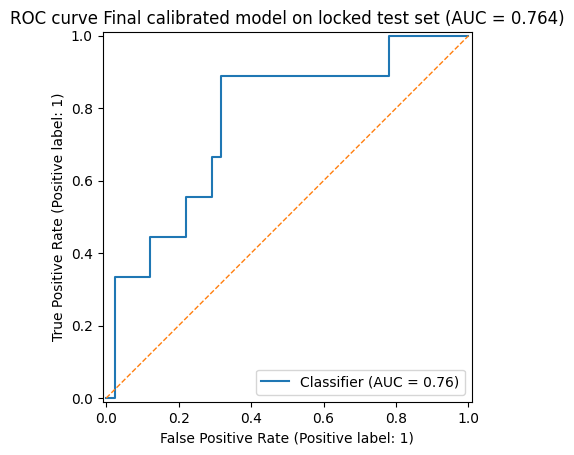

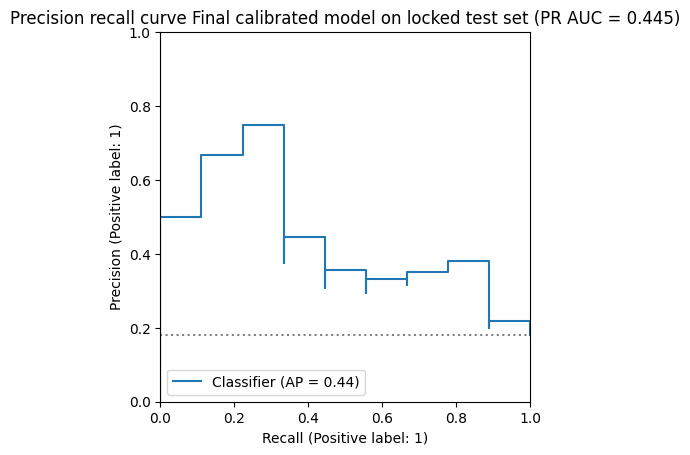

Test results are estimates from 50 synthetic records and are highly uncertain


In [26]:
# Single final test evaluation after the policy is locked
if not POLICY_LOCKED:
    raise RuntimeError("Threshold policy must be locked before test evaluation")

y_score_test = positive_scores(calibrated_clf, X_test)
test_summary = summary_at_threshold(y_test, y_score_test, FINAL_THR).iloc[0]

test_recall_ci = wilson_interval(
    int(test_summary["TP"]), int(test_summary["TP"] + test_summary["FN"])
)
test_precision_ci = wilson_interval(
    int(test_summary["TP"]), int(test_summary["TP"] + test_summary["FP"])
)

final_test_table = pd.DataFrame([{
    "locked threshold": FINAL_THR,
    "test n": len(y_test),
    "recorded OUD cases": int((y_test == 1).sum()),
    "TP": int(test_summary["TP"]),
    "FP": int(test_summary["FP"]),
    "FN": int(test_summary["FN"]),
    "recall": float(test_summary["recall"]),
    "recall 95% CI": f"{test_recall_ci[0]:.3f} to {test_recall_ci[1]:.3f}",
    "precision": float(test_summary["precision"]),
    "precision 95% CI": f"{test_precision_ci[0]:.3f} to {test_precision_ci[1]:.3f}",
    "alert count": int(test_summary["TP"] + test_summary["FP"]),
    "alerts per 1,000": float(test_summary["alerts_per_1000"]),
    "ROC AUC": float(roc_auc_score(y_test, y_score_test)),
    "PR AUC": float(average_precision_score(y_test, y_score_test)),
}])
display(final_test_table.round(3))

auc_report(
    y_true=y_test,
    y_score=y_score_test,
    name="Final calibrated model on locked test set",
)
print("Test results are estimates from 50 synthetic records and are highly uncertain")

The final results support only a classroom demonstration of retrospective risk stratification. They do not validate prospective prediction, diagnosis, treatment decisions or a real clinical pathway. Any prospective study would need temporally separated predictors and outcomes, external validation, workflow testing and governance review


# 9. Intro to RAI toolkit
While global metrics e.g. ROC AUC and PR AUC, are essential for evaluating model performance, they don't tell the full story. To **responsibly deploy a model in a clinical setting, we must look deeper**. We need to understand:

- **Why** it makes certain predictions (Interpretability)
- **Where** it fails and for whom (Error Analysis)
- **How** we might change an outcome (Counterfactuals)
- **What** the real-world impact of an intervention might be (Causal Inference)

Tools such as MS's RAI toolkit provides a unified dashboard to explore these questions. In this section, we will build the dashboard step-by-step for our calibrated opioid risk model:

1. Setup: Prepare the data and model and initialize the main RAIInsights object.
2. Add Components: Add the advanced analytical tools like the explainer and error analysis.
3. Compute & Launch: Run the analyses and launch the interactive dashboard.

## 9.1 Setup: Creating the RAIInsights Object

1. Combine Data: The toolkit requires the training and testing data to be in pandas DataFrames (including features and target)
2. Define Metadata: We must tell the toolkit which features are categorical and which represents a "sensitive" group for fairness analysis e.g. Low_inc as "Identity group"
3. Wrap the Model: We wrap our calibrated classifier in a helper class (in utils) to apply the threshold during prediction

This set up creates a RAIInsights object, a container for all the analytical components we'll add next

In [ ]:
# 1. Define the exact feature set the model was trained on
feature_cols = list(X_train.columns)

# 2. Create RAI-compatible DataFrames with features and the target column
target_col = TARGET
train_df_rai = X_train.copy()
train_df_rai[target_col] = y_train
test_df_rai = X_test.copy()
test_df_rai[target_col] = y_test

if "Surgery" in train_df_rai.columns:
    train_df_rai["Surgery"] = train_df_rai["Surgery"].astype(str)
    test_df_rai["Surgery"] = test_df_rai["Surgery"].astype(str)

# 3. Define feature metadata
categorical_features = [c for c in cat_like_binary_cols if c in feature_cols]
if "Surgery" in feature_cols and "Surgery" not in categorical_features:
    categorical_features.append("Surgery")

identity_feature = "Low_inc" if "Low_inc" in feature_cols else None
feature_metadata = FeatureMetadata(
    identity_feature_name=identity_feature,
    categorical_features=categorical_features,
)

# 4. Lock the final model threshold from the recall-floor policy
FINAL_THR = float(thr_rec)
print(f"Final threshold selected from the recall-floor policy: {FINAL_THR:.3f}")

# 5. Wrap the classifier to make predictions based on our final threshold
policy_model = make_thresholded_estimator(calibrated_clf, threshold=FINAL_THR)

# 6. Create the main RAIInsights object
rai_insights = RAIInsights(
    model=policy_model,
    train=train_df_rai,
    test=test_df_rai,
    target_column=target_col,
    task_type="classification",
    feature_metadata=feature_metadata
)

## 9.2 Adding Analytical Components to the Dashboard

We add the core analytical components to our RAIInsights object"

- Interpretability (.explainer): To understand the why behind model predictions
- Error Analysis (.error_analysis): To diagnose where the model is failing
- Counterfactuals (.counterfactual): To generate "what-if" scenarios for individual patients
- Causal Inference (.causal): To estimate the real-world impact of interventions

In [ ]:
# Add the core analytical components.
# Data Balance and Model Analysis views are generated automatically.
rai_insights.explainer.add()
rai_insights.error_analysis.add()

# Use the exact observed categories from TRAIN for Surgery
surgery_categories = (
    train_df_rai["Surgery"].astype(str).dropna().unique().tolist()
    if "Surgery" in train_df_rai.columns else None
)

# Define features for counterfactual and causal analysis (12, 34, 31)
permitted_range = {
    "rx_ds": [float(X_train["rx_ds"].min()), float(X_train["rx_ds"].max())],
    "Surgery": ["0", "1"]
}

if surgery_categories is not None:
    permitted_range["Surgery"] = sorted(surgery_categories)  # e.g. ['0', '1']

features_to_vary = [
    "rx_ds", "Surgery"] if "Surgery" in feature_cols else ["rx_ds"]

# Add the remaining components
rai_insights.counterfactual.add(
    total_CFs=10,
    method="random",  # or genetic / kdtree
    desired_class="opposite",  # or "same"
    features_to_vary=features_to_vary,
    permitted_range=permitted_range
)

# Define treatment features for causal analysis
# Can a healthcare provider directly and ethically change this factor to observe a potential change in the patient's OD risk?
# e.g. we can't change "Low_inc" (socioeconomic status) or "V" (traumatic injury) directly
# <- "What if we successfully managed this patient's underlying condition?"
treatment_features = ["Surgery", "rx_ds"]
rai_insights.causal.add(treatment_features=treatment_features)

print("Explainer, Error Analysis, Counterfactual, and Causal components added ✅")

## 9.3 Compute Insights and Launch Dashboard
Now we run the compute() method, which executes all the analyses in the background. Launch the interactive dashboard to explore the results

In [ ]:
# Compute all the added insights. This may take a few minutes.
print("Computing RAI insights... Please wait.")
rai_insights.compute()
print("Computation complete.")
# Launch the interactive dashboard
ResponsibleAIDashboard(rai_insights)